# Automatic Music Transcription
* Audio to guitar tablature

# TODO
* Consider using an embedding layer at the input, as it can help in learning a more meaningful representation of the tokens


In [26]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
from sklearn.model_selection import train_test_split
import IPython.display as ipd

import copy
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Preprocessing

In [2]:
# Load in the mp3 file, get the sample rate, and get the data
# from the file

import numpy as np
import matplotlib.pyplot as plt
import librosa

# Load in the mp3 file
y, sr = librosa.load('dataset/john-mayer/3_Why_Georgia.mp3')

In [3]:
# Get the data from the file
data = librosa.feature.mfcc(y=y, sr=sr)

In [4]:
def plotMFCC(data):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(data, x_axis='time')
    plt.colorbar()
    plt.title('MFCC')
    plt.tight_layout()
    plt.show()

# plotMFCC(data)

In [5]:
# install pyguitarpro
# !pip install pyguitarpro
# !pip install --upgrade attrs


In [6]:
import guitarpro

# Load in the gp5 file
song = guitarpro.parse('dataset/john-mayer/3_why-georgia.gp5')

In [7]:
def tokenize_note_effect(note_effect):
    effect_tokens = []
    
    if note_effect.accentuatedNote:
        effect_tokens.append('accentuated')
        
    if note_effect.bend:
        effect_tokens.append(f'bend:{note_effect.bend.type}')
        
    if note_effect.ghostNote:
        effect_tokens.append('ghost')
        
    if note_effect.grace:
        effect_tokens.append(f'grace:{note_effect.grace.fret}:{note_effect.grace.duration}:{note_effect.grace.transition}')
        
    if note_effect.hammer:
        effect_tokens.append('hammer')
        
    if note_effect.harmonic:
        effect_tokens.append(f'harmonic:{type(note_effect.harmonic).__name__}')
        
    if note_effect.heavyAccentuatedNote:
        effect_tokens.append('heavy_accentuated')
        
    if note_effect.leftHandFinger != 'open':
        effect_tokens.append(f'left_finger:{note_effect.leftHandFinger}')
        
    if note_effect.letRing:
        effect_tokens.append('let_ring')
        
    if note_effect.palmMute:
        effect_tokens.append('palm_mute')
        
    if note_effect.rightHandFinger != 'open':
        effect_tokens.append(f'right_finger:{note_effect.rightHandFinger}')
        
    if note_effect.slides:
        for slide in note_effect.slides:
            effect_tokens.append(f'slide:{slide}')
            
    if note_effect.staccato:
        effect_tokens.append('staccato')
        
    if note_effect.tremoloPicking:
        effect_tokens.append(f'tremolo:{note_effect.tremoloPicking.duration.value}')
        
    if note_effect.trill:
        effect_tokens.append(f'trill:{note_effect.trill.fret}:{note_effect.trill.duration.value}')
        
    if note_effect.vibrato:
        effect_tokens.append('vibrato')
        
    # Join the tokens with a comma and return the result
    effect_token = ','.join(effect_tokens)
    return effect_token


In [8]:
def tokenize_note_simple(note):
    """
    Tokenizes a note based on its string and fret number.
    """
    # Calculate the token index based on string and fret
    # Token range for fretted notes: 1 to 120
    # Token range for open strings: 121 to 126
    if note.value == 0:  # Open string
        token_index = 121 + (6 - note.string)
    else:
        token_index = (note.string - 1) * 20 + note.value

    return token_index

def tokenize_song_simple(song):
    """
    Tokenizes an entire song using a simplified scheme.
    """
    all_measures_tokens = []

    # Start token for the song
    all_measures_tokens.append([128])  # 128 is the start token

    for track in song.tracks:
        for measure in track.measures:
            measure_tokens = []
            for voice in measure.voices:
                for beat in voice.beats:
                    if track.isPercussionTrack:
                        continue  # Skip percussion tracks
                    else:
                        for note in beat.notes:
                            token = tokenize_note_simple(note)
                            measure_tokens.append(token)

                    # Assuming each beat is a 'wait' token
                    measure_tokens.append(127)  # 127 is the wait/rest token

            # Repeat measures if necessary
            if measure.repeatClose > 0:
                for _ in range(measure.repeatClose):
                    all_measures_tokens.append(measure_tokens)
            else:
                all_measures_tokens.append(measure_tokens)

    # End token for the song
    all_measures_tokens.append([129])  # 129 is the end token

    return all_measures_tokens


In [10]:
# tokenize the acoustic song track only
acoustic_song = copy.deepcopy(song)
acoustic_song.tracks = [acoustic_song.tracks[0]]

tokens = tokenize_song_simple(acoustic_song)

In [11]:
def count_acoustic_notes():
    acoustic_notes = []
    max_num_notes = 5
    counter = 0
    
    for track in acoustic_song.tracks:
        for measure in track.measures:
            for voice in measure.voices:
                for beat in voice.beats:
                    for note in beat.notes:
                        acoustic_notes.append(note)

                        counter += 1
                        if counter > max_num_notes:
                            return acoustic_notes

acoustic_notes = count_acoustic_notes()
# len(acoustic_notes), acoustic_notes[:5], tokenize_note(acoustic_notes[:5])
# for note in acoustic_notes[:5]:
#     print(note)
#     print(tokenize_note(note))
#     print()

In [12]:
# Initialize an empty dictionary to store the mapping from tokens to integers
token_to_int = {}
int_to_token = {}
next_int = 0  # Start assigning from 0

# Function to dynamically update the dictionary
def update_token_mapping(token, token_to_int, int_to_token, next_int):
    if token not in token_to_int:
        token_to_int[token] = next_int
        int_to_token[next_int] = token
        next_int += 1
    return next_int

# Update the dictionary with the tokens from the file
for measure in tokens:
    for token in measure:
        next_int = update_token_mapping(token, token_to_int, int_to_token, next_int)

# Show some statistics and samples to verify
num_unique_tokens = len(token_to_int)
sample_items_token_to_int = list(token_to_int.items())[:45]
sample_items_int_to_token = list(int_to_token.items())[:45]

num_unique_tokens, sample_items_token_to_int, sample_items_int_to_token


(37,
 [(128, 0),
  (127, 1),
  (123, 2),
  (122, 3),
  (103, 4),
  (23, 5),
  (124, 6),
  (42, 7),
  (121, 8),
  (64, 9),
  (85, 10),
  (125, 11),
  (83, 12),
  (44, 13),
  (62, 14),
  (65, 15),
  (126, 16),
  (82, 17),
  (102, 18),
  (3, 19),
  (21, 20),
  (63, 21),
  (101, 22),
  (81, 23),
  (45, 24),
  (47, 25),
  (61, 26),
  (7, 27),
  (28, 28),
  (69, 29),
  (87, 30),
  (5, 31),
  (25, 32),
  (67, 33),
  (43, 34),
  (2, 35),
  (129, 36)],
 [(0, 128),
  (1, 127),
  (2, 123),
  (3, 122),
  (4, 103),
  (5, 23),
  (6, 124),
  (7, 42),
  (8, 121),
  (9, 64),
  (10, 85),
  (11, 125),
  (12, 83),
  (13, 44),
  (14, 62),
  (15, 65),
  (16, 126),
  (17, 82),
  (18, 102),
  (19, 3),
  (20, 21),
  (21, 63),
  (22, 101),
  (23, 81),
  (24, 45),
  (25, 47),
  (26, 61),
  (27, 7),
  (28, 28),
  (29, 69),
  (30, 87),
  (31, 5),
  (32, 25),
  (33, 67),
  (34, 43),
  (35, 2),
  (36, 129)])

In [13]:
# Convert the tokens to their corresponding integer values using the mapping
# integer_representation = [token_to_int[token] for token in tokens]

token_measures = []
for measure in tokens:
    integer_representation = []    
    for token in measure:
        integer_representation.append(token_to_int[token])
    token_measures.append(integer_representation)

In [14]:
# convert the integer representation back to the original tokens
reconstructed_tokens = []
for measure in token_measures:
    reconstructed_tokens.append([int_to_token[i] for i in measure])

## Audio Segmentation
* Split the audio into segments of roughly the same length as the tablature measures.

In [15]:
len(y)

5931006

In [16]:
# Given parameters
sample_rate = sr
chunk_duration = 2.5  # Chunk duration in seconds
hop_length = 512  # This is the default hop length for librosa's mfcc calculation

# Calculate the number of samples per chunk
samples_per_chunk = int(sample_rate * chunk_duration)

# Calculate the number of chunks
num_chunks = len(y) // samples_per_chunk + 1

# calculate total number of frames
total_frames = len(y) // hop_length + 1

# Calculate the number of frames per chunk
# Formula: Number of Frames = (Number of Samples in Segment - Frame Length) / Hop Length + 1
# Assuming the frame length is equal to the hop length for simplicity
frames_per_chunk = (samples_per_chunk) // hop_length + 1

In [17]:
# Assuming 'y' is your original audio waveform
audio_segments = []
# let start be at the 0.5 second mark
start = int(0.5 * sample_rate)  
for start_frame in range(start, len(y), frames_per_chunk * hop_length):
    end_frame = start_frame + frames_per_chunk * hop_length
    segment = y[start_frame:end_frame]
    audio_segments.append(segment)

# 'audio_segments' now contains chunks of the original audio waveform

In [18]:
# # count the number of measures in the gp5 file
# num_measures = 0
# for track in song.tracks:
#     for measure in track.measures:
#         num_measures += 1
#     print(f'{track.name} measures: {num_measures}')


In [19]:
segmented_evenly = abs(len(token_measures) - len(audio_segments)) < 3
assert(segmented_evenly)        # make sure the audio segments and measures are segmented evenly
print(len(token_measures), len(audio_segments))

108 108


In [20]:
measure_num = 2
audio_segment_num = 0

# get the audio segment
audio_segment = audio_segments[audio_segment_num]
# get the measure
measure = token_measures[measure_num]

# play the audio segment
# ipd.Audio(audio_segment, rate=sample_rate)
reconstructed_tokens[measure_num]

[123,
 122,
 103,
 127,
 23,
 124,
 127,
 42,
 127,
 122,
 121,
 127,
 23,
 124,
 127,
 122,
 127,
 64,
 85,
 127,
 124,
 127,
 123,
 122,
 127,
 85,
 127,
 64,
 127,
 124,
 127]

In [21]:
len(token_measures), len(audio_segments)

# delete the first two measures which are the song metadata and initial wait token
del token_measures[:2]      # TODO: TEST THIS!!!

In [22]:
audio_segment_num = 10
measure_num = audio_segment_num

# get the audio segment
audio_segment = audio_segments[audio_segment_num]
# get the measure
measure = token_measures[measure_num]
print(audio_segment)
print(measure)
print(len(audio_segment), len(measure))

[-0.01393945 -0.02781955 -0.02557069 ...  0.05538661  0.02369128
  0.0007503 ]
[2, 3, 4, 1, 5, 6, 1, 7, 1, 3, 8, 1, 5, 6, 1, 3, 1, 9, 10, 1, 6, 1, 2, 3, 1, 10, 1, 9, 1, 6, 1]
55296 31


In [23]:
# show the tokens
reconstructed_tokens[measure_num]

[83,
 127,
 23,
 44,
 62,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 65,
 127,
 62,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 65,
 127,
 83,
 127,
 23,
 42,
 62,
 127,
 123,
 122,
 127,
 62,
 127,
 23,
 42,
 62,
 127,
 44,
 127]

In [27]:
# play the first measure audio segment
ipd.Audio(audio_segment, rate=sample_rate)

## Dataset

10 20 (20, 109)


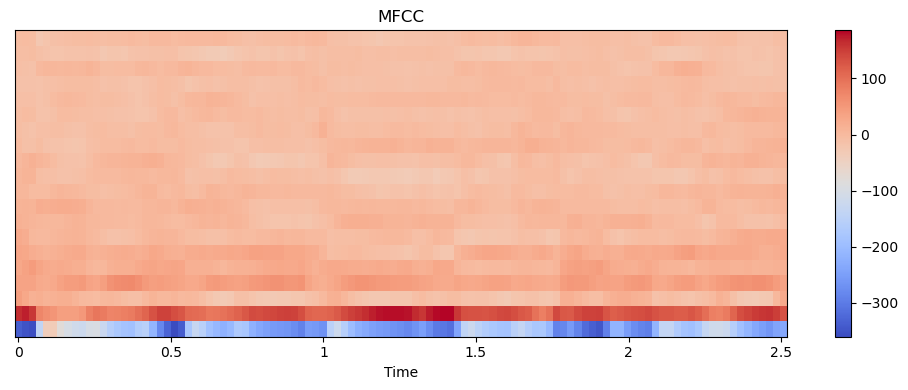

In [28]:
len(audio_segments)

# get the MFCC for the first 10 audio segments
audio_segments_mfcc = []
for audio_segment in audio_segments[:10]:
    audio_segments_mfcc.append(librosa.feature.mfcc(y=audio_segment, sr=sample_rate))

print(len(audio_segments_mfcc), len(audio_segments_mfcc[0]), audio_segments_mfcc[0].shape)

# plot the MFCC for the first audio segments
plotMFCC(audio_segments_mfcc[0])
    


In [29]:
X = torch.tensor(audio_segments_mfcc)
y = token_measures[:10]

/var/folders/1f/qjk02_3s70zd4sxj573fj7400000gn/T/ipykernel_48710/3191281816.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1670525473998/work/torch/csrc/utils/tensor_new.cpp:233.)
  X = torch.tensor(audio_segments_mfcc)


In [30]:
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Now X_train, y_train are the training set, and X_test, y_test are the test set
X_train, X_test, y_train, y_test

(tensor([[[-6.9729e+01, -6.4604e+01, -7.8545e+01,  ..., -2.5071e+01,
           -3.4159e+01, -7.0207e+01],
          [ 1.0582e+02,  9.6872e+01,  8.3974e+01,  ...,  7.3367e+01,
            9.7897e+01,  1.2018e+02],
          [-2.2194e+01, -3.3566e+01, -3.8691e+01,  ..., -3.0945e+01,
           -2.6276e+01, -1.8078e+01],
          ...,
          [-1.2152e+01, -1.3700e+01, -1.0826e+01,  ...,  6.2539e-01,
            1.5107e+00,  2.2860e+00],
          [-7.3603e+00, -1.0428e+01, -1.7312e+01,  ..., -1.2630e+01,
           -1.0711e+01, -1.1868e+01],
          [-3.1201e+00, -6.0206e+00, -8.3393e+00,  ..., -1.9705e+01,
           -1.6374e+01, -1.0122e+01]],
 
         [[-3.3713e+02, -3.5074e+02, -3.5618e+02,  ..., -2.6251e+02,
           -2.4091e+02, -2.3640e+02],
          [ 1.6403e+02,  1.7213e+02,  1.5523e+02,  ...,  1.5818e+02,
            1.4961e+02,  1.3185e+02],
          [ 4.1547e+01,  2.9043e+01,  1.3172e+01,  ..., -2.4283e+01,
            2.5119e+00,  2.4461e+01],
          ...,
    

In [31]:
for transcription in y_train:
    print(len(transcription))

31
31
41
31
31
31
31
31


In [32]:
# get the first audio segment
audio_segment_mfcc = X_train[0]
audio_segment_mfcc.shape

torch.Size([20, 109])

In [33]:
audio_segment_mfcc = audio_segment_mfcc.unsqueeze(0)

In [34]:
audio_segment_mfcc.shape

torch.Size([1, 20, 109])

In [40]:
class CNNAudioTranscriber(nn.Module):
    def __init__(self, num_mfcc_features, num_output_classes):
        super(CNNAudioTranscriber, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Calculate the flattened size
        flattened_size = 64 * (num_mfcc_features // 8) * (109 // 8)
        self.fc1 = nn.Linear(flattened_size, 128)
        self.fc2 = nn.Linear(128, num_output_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * (num_mfcc_features // 8) * (109 // 8))
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# calcualte num_mfcc_features
num_mfcc_features = audio_segment_mfcc.shape[1]  # Assuming mfccs is a NumPy array with shape (num_mfcc_features, time_steps)

# calculate num_output_classes
num_output_classes = len(token_to_int)

# Now, create the model instance and perform the forward pass with the actual MFCC data
model = CNNAudioTranscriber(num_mfcc_features, num_output_classes)
model.eval()
with torch.no_grad():
    prediction = model(audio_segment_mfcc)


In [41]:
print(prediction.shape, prediction[0][:10])



torch.Size([1, 37]) tensor([ 0.2903,  0.0343,  0.0240, -0.4238,  0.4807,  0.2871, -0.0707, -0.1798,
        -0.5489,  0.8443])


In [42]:
# get the length of our first transcription
print(len(y_train[0]))
print(y_train[0][:10])

31
[2, 3, 4, 1, 5, 6, 1, 7, 1, 3]
